# 1. Descriptive Statistics: 

## Calculation of summary statistics (mean, median, mode, range) for numeric fields:

## Data:
- Calls
- Spend
- Deals
- Contact

In [1]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [2]:
with open("crm_clean_data.pickle", "rb") as f:
     calls, contacts, spend, deals = pickle.load(f)

## Summary statistics for Calls:

- mean
- median
- mode
- range

In [3]:
# Creating a universal function for numeric columns to display descriptive statistics and plot a graph

def numeric_summary(df, column):
    values = df[column].dropna()
    
    mean_val = values.mean()
    median_val = values.median()
    mode_val = values.mode()[0] if not values.mode().empty else 'No mode'
    span = values.max() - values.min()
    
    print(f'\nMean: {mean_val}\nMedian: {median_val}\nMode: {mode_val}\nRange: {span}')
    
    plt.figure(figsize=(12, 6), facecolor='none')
    ax = sns.histplot(values, bins='auto', kde=False, color='steelblue')
    ax.set_facecolor('none')
    plt.title(f'Distribution of data in "{column}"', fontsize=14, pad=20)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.tight_layout()
    plt.show()

In [4]:
print(contacts[['created_time', 'modified_time']].agg(['min', 'max', 'median']))
print("Mode created_time (date):", contacts['created_time'].dt.date.mode()[0])
print("Mode modified_time (date):", contacts['modified_time'].dt.date.mode()[0])

              created_time       modified_time
min    2023-06-27 11:28:00 2023-07-06 10:54:00
max    2024-06-21 15:30:00 2024-06-21 15:32:00
median 2024-02-01 18:32:00 2024-02-28 22:44:00
Mode created_time (date): 2024-04-16
Mode modified_time (date): 2024-04-16


In [5]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   calls_id              95874 non-null  object        
 1   call_start_time       95874 non-null  datetime64[ns]
 2   calls_manager         95874 non-null  category      
 3   contact_id            95874 non-null  object        
 4   call_type             95874 non-null  category      
 5   call_duration_sec     95874 non-null  int64         
 6   call_status           95874 non-null  category      
 7   outgoing_call_status  86875 non-null  category      
 8   scheduled_in_CRM      95874 non-null  bool          
dtypes: bool(1), category(4), datetime64[ns](1), int64(1), object(2)
memory usage: 3.4+ MB



Mean: 214.09094234312343
Median: 21.0
Mode: 5
Range: 7624


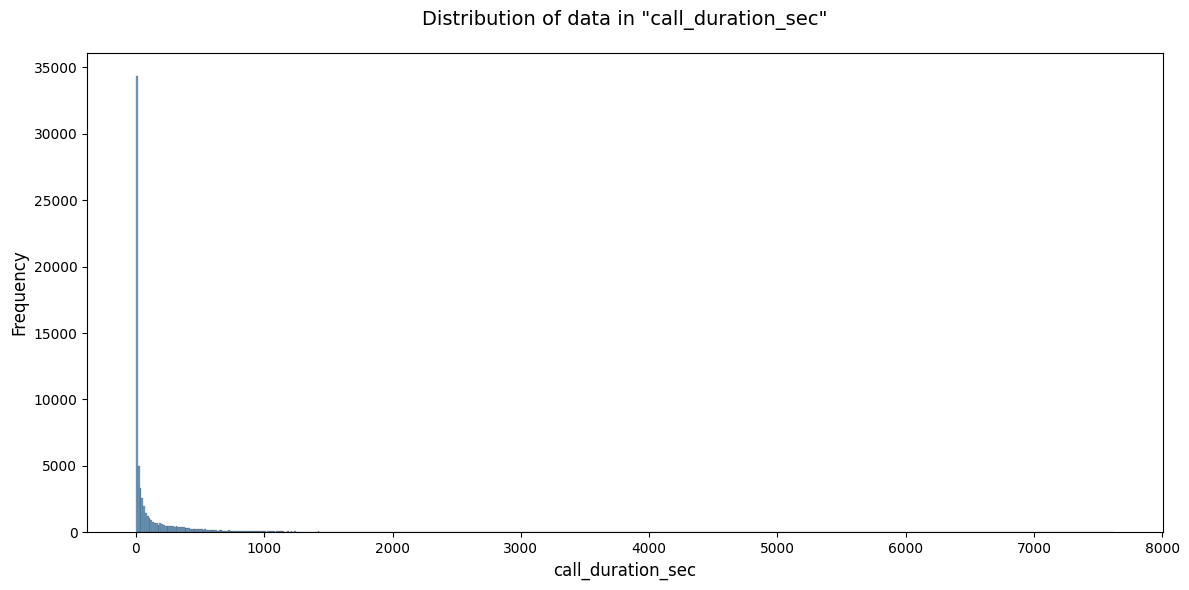

In [6]:
answered_calls = calls[calls['call_duration_sec'] > 0]
numeric_summary(answered_calls, 'call_duration_sec')

The median of 21 seconds and the mode of 5 seconds confirm that the vast majority of calls end immediately after connection.

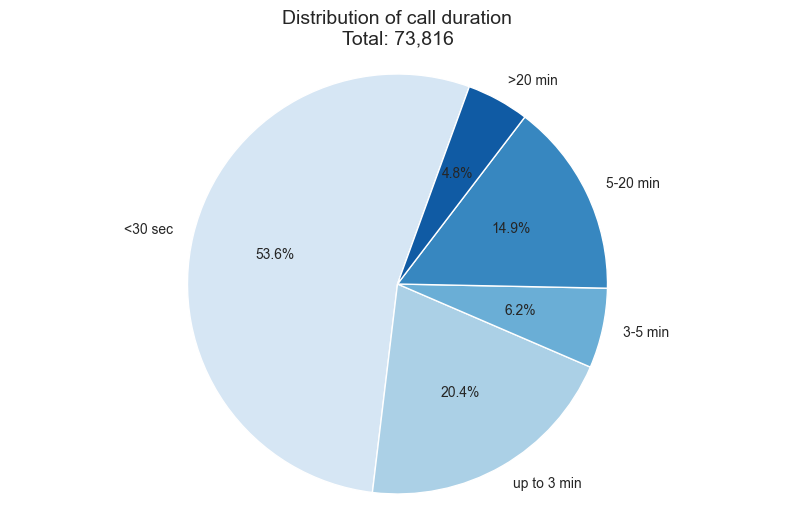

In [7]:
# Analysis of call duration
# Previously, missing values were filled with 0 because these were unanswered calls
# Now we consider only those where the call was answered

answered_calls = calls[calls['call_duration_sec'] > 0]['call_duration_sec']

bins = [0, 30, 180, 300, 1200, float('inf')]
labels = ['<30 sec', 'up to 3 min', '3-5 min', '5-20 min', '>20 min']

counts = pd.cut(answered_calls, bins=bins, labels=labels).value_counts().sort_index()

sns.set_style('white')
plt.figure(figsize=(10, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('Blues', len(counts)), startangle=70)
plt.title(f'Distribution of call duration\nTotal: {len(answered_calls):,}', fontsize=14)
plt.axis('equal')
plt.savefig('analysis_of_call_duration.svg')
plt.show()

In [8]:
counts

call_duration_sec
<30 sec        39601
up to 3 min    15083
3-5 min         4544
5-20 min       11034
>20 min         3554
Name: count, dtype: int64

### Key observations:

**1. Dominant category - very short calls (<30 seconds)**

- 54% of all answered calls (largest group)

**2. Long calls (>20 minutes):**
- 5% of calls - a significant group
- Requires further analysis: complex questions, problems

### Conclusions:

More than half of all calls (53.6%) last less than 30 seconds, which confirms critically low quality of initial contact or the database.  
The share of meaningful conversations (more than 5 minutes) is less than 20% of the total volume!  
This call structure indicates extremely low operational efficiency: the main resource of the sales department is spent on "empty" calls that generate no revenue.

## Analysis of categorical fields in Calls

In [9]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   calls_id              95874 non-null  object        
 1   call_start_time       95874 non-null  datetime64[ns]
 2   calls_manager         95874 non-null  category      
 3   contact_id            95874 non-null  object        
 4   call_type             95874 non-null  category      
 5   call_duration_sec     95874 non-null  int64         
 6   call_status           95874 non-null  category      
 7   outgoing_call_status  86875 non-null  category      
 8   scheduled_in_CRM      95874 non-null  bool          
dtypes: bool(1), category(4), datetime64[ns](1), int64(1), object(2)
memory usage: 3.4+ MB


### calls_manager

In [10]:
calls['calls_manager'].value_counts()

calls_manager
Yara Edwards       9059
Julia Nelson       7446
Ian Miller         7215
Charlie Davis      7213
Diana Evans        6857
Ulysses Adams      6085
Amy Green          5982
Nina Scott         5581
Victor Barnes      5439
Kevin Parker       5406
Paula Underwood    4580
Quincy Vincent     4384
Jane Smith         3753
Cara Iverson       3300
John Doe           2986
Ben Hall           2947
Alice Johnson      1251
Mason Roberts      1166
Derek James         948
George King         850
Zachary Foster      523
Eva Kent            498
Fiona Jackson       470
Sam Young           457
Rachel White        441
Xander Dean         304
Ethan Harris        280
Hannah Lee          175
Wendy Clark         162
Bob Brown            99
Oliver Taylor        10
Tina Zhang            5
Laura Quinn           2
Name: count, dtype: int64

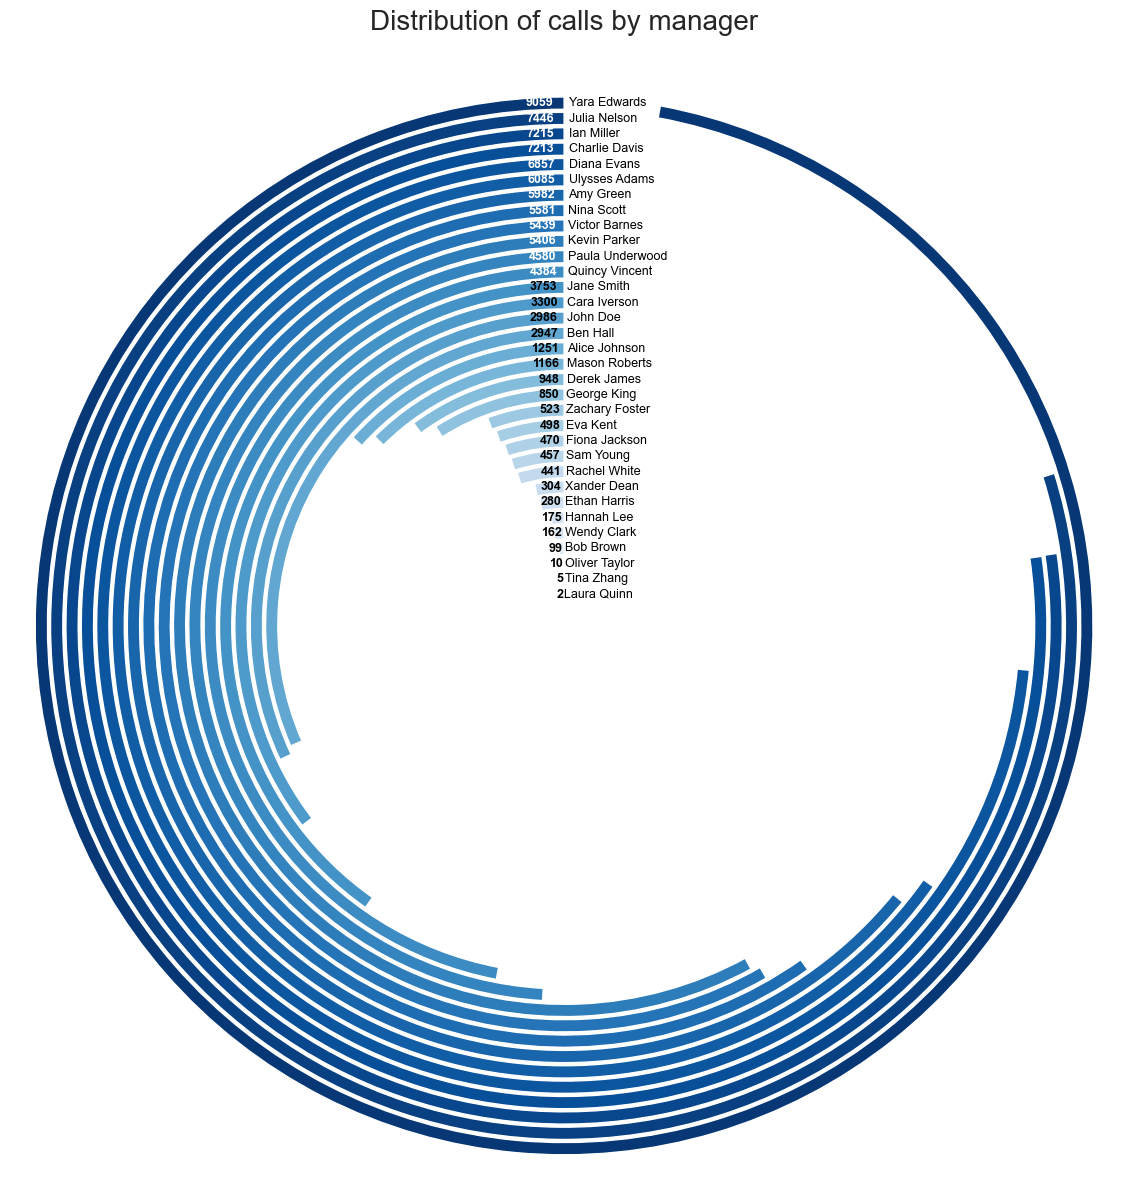

In [11]:
calls_manager_counts = calls['calls_manager'].value_counts()
calls_sorted = calls_manager_counts.sort_values()

labels = calls_sorted.index.tolist()
values = calls_sorted.values

max_val = max(values) * 1.03
values_scaled = [v * 2 * np.pi / max_val for v in values]

palette = sns.color_palette('Blues', len(values))

plt.figure(figsize=(12, 12))
sns.set_style('darkgrid')

ax = plt.subplot(projection='polar')

for i in range(len(values)):
    bar_len = values_scaled[i]

    ax.barh(i, bar_len, color=palette[i])

    # label at the beginning of the bar (to the right of the start)
    ax.text(-0.01,      # ← small shift to the right from the start
            i,
            labels[i],
            va='center',
            ha='left',
            fontsize=9,
            color='black')
    
    # label with the count inside the bar at the beginning (gradient color based on bar darkness)
    # Get the bar color in RGB format
    bar_color = palette[i]
    # If the bar is dark, make the text light; if light, make it dark
    # Simple brightness formula: 0.299*R + 0.587*G + 0.114*B taken from an online resource
    brightness = 0.299 * bar_color[0] + 0.587 * bar_color[1] + 0.114 * bar_color[2]
    text_color = 'white' if brightness < 0.5 else 'black'
    
    ax.text(0.02,  # 5% of the bar length, at the beginning
            i,
            f'{values[i]}',
            va='center',
            ha='right',
            fontsize=9,
            color=text_color,
            fontweight='bold')

ax.set_rgrids([])
ax.set_thetagrids([])

ax.spines['polar'].set_visible(False)
ax.grid(False)

ax.set_theta_zero_location('N')
ax.set_theta_direction(1)

plt.title('Distribution of calls by manager', fontsize=20, pad=30)

# Remove background
ax.set_facecolor('none')
plt.gca().set_facecolor('none')

plt.tight_layout()
plt.savefig('analysis_of_calls_manager.svg')
plt.show()

### call_type

In [12]:
call_type_count = calls['call_type'].value_counts()
call_type_count

call_type
Outbound    86875
Missed       5921
Inbound      3078
Name: count, dtype: int64

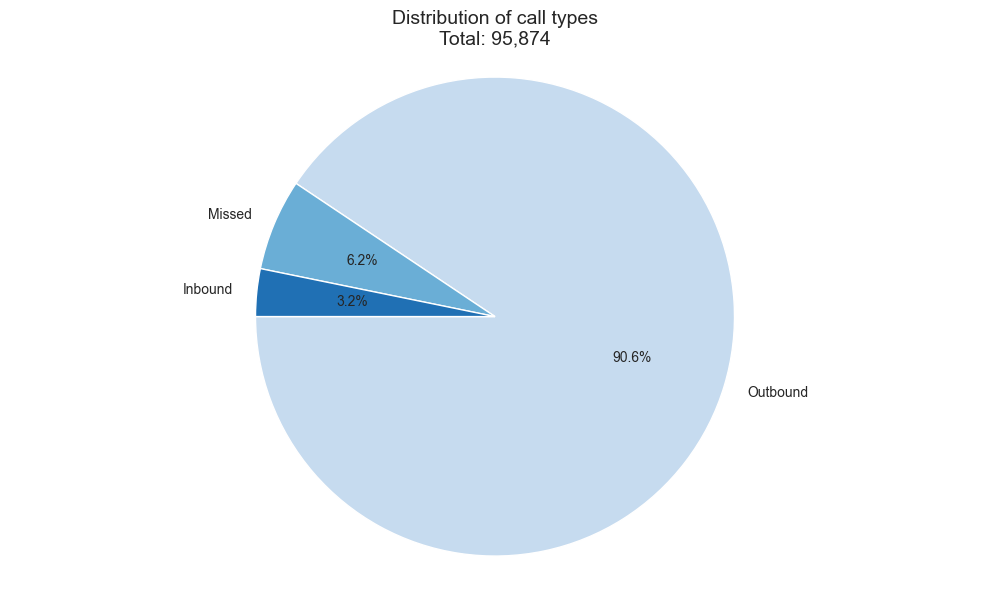

In [13]:
# Distribution by call type

plt.figure(figsize=(10, 6))
plt.pie(call_type_count, labels=call_type_count.index, autopct='%1.1f%%',
        colors=sns.color_palette('Blues', len(call_type_count)), startangle=180)
plt.title(f'Distribution of call types\nTotal: {len(calls):,}', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('analysis_of_call_type.svg')
plt.show()

In [14]:
call_type_count

call_type
Outbound    86875
Missed       5921
Inbound      3078
Name: count, dtype: int64

In [15]:
calls

,calls_id,call_start_time,calls_manager,contact_id,call_type,call_duration_sec,call_status,outgoing_call_status,scheduled_in_CRM
0,5805028000000805001,2023-06-30 08:43:00,John Doe,-1,Inbound,171,Received,NaN,False
1,5805028000000768006,2023-06-30 08:46:00,John Doe,-1,Outbound,28,Attended Dialled,Completed,False
2,5805028000000764027,2023-06-30 08:59:00,John Doe,-1,Outbound,24,Attended Dialled,Completed,False
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5805028000000645014,Outbound,6,Attended Dialled,Completed,False
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5805028000000645014,Outbound,11,Attended Dialled,Completed,False
...,...,...,...,...,...,...,...,...,...
95869,5805028000056889515,2024-06-21 15:30:00,Ulysses Adams,5805028000056564231,Outbound,6,Attended Dialled,Completed,False
95870,5805028000056875317,2024-06-21 15:30:00,Victor Barnes,5805028000054867023,Outbound,8,Attended Dialled,Completed,False
95871,5805028000056832495,2024-06-21 15:30:00,Kevin Parker,5805028000010617278,Outbound,5,Attended Dialled,Completed,False
95872,5805028000056893619,2024-06-21 15:30:00,Victor Barnes,5805028000056839048,Outbound,0,Unattended Dialled,Completed,False


### call_status

In [16]:
calls['call_status'].value_counts()

call_status
Attended Dialled              70703
Unattended Dialled            16030
Missed                         5922
Received                       3077
Overdue                          60
Scheduled Attended Delay         22
Cancelled                        20
Scheduled Unattended Delay       17
Scheduled Attended               14
Scheduled Unattended              6
Scheduled                         3
Name: count, dtype: int64

In [17]:
# Comparative analysis of managers by call status

status_list = ['Attended Dialled', 'Unattended Dialled', 'Missed', 'Received']
filtered = calls[calls['call_status'].isin(status_list)]

pivot = pd.crosstab(filtered['calls_manager'], filtered['call_status'])
all_managers = filtered['calls_manager'].value_counts().index
pivot_top = pivot.loc[all_managers]

# Normalize into percentages
pivot_norm = pivot_top.div(pivot_top.sum(axis=1), axis=0) * 100

# Calculate total number of calls per manager
total_calls = pivot_top.sum(axis=1)

# Chart
fig = go.Figure()
colors = ['#083775', '#1865ac', '#FF6464', '#9cc8e0']

for i, status in enumerate(status_list):
    if status in pivot_norm.columns:
        fig.add_trace(go.Bar(
            name=status,
            x=pivot_norm.index,
            y=pivot_norm[status],
            textposition='none',
            marker_color=colors[i]
        ))

# Add annotations with total number of calls above each bar
for manager, total in total_calls.items():
    fig.add_annotation(
        x=manager,
        y=101,  # small offset from the base
        text=str(int(total)),
        showarrow=False,
        font=dict(size=10, color='black'),
        xanchor='center',
        yanchor='bottom',
        textangle=-70
    )

# Setting up title and legend
fig.update_layout(
    barmode='stack',
    height=550,
    width=1000,
    template='plotly_white',
    title={
        'text': 'Manager efficiency: distribution of call statuses',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    legend={
        'orientation': 'h',
        'yanchor': 'bottom',
        'y': 1.04,
        'xanchor': 'center',
        'x': 0.5
    }
)

fig.update_xaxes(tickangle=-90)
fig.update_yaxes(ticksuffix='%')
fig.show()

### Key observations:

**1. Key problem — high percentage of missed calls among three managers**

- **John Doe** — out of 2,986 calls, missed 40% (about 1,194 calls)
- **Fiona Jackson** — out of 470 calls, missed 83% (about 390 calls) — **critical situation**
- **Tina Zhang** — out of 5 calls, missed 60% (3 calls)

> ⚠️ **Fiona Jackson** loses 8 out of 10 calls — requires urgent intervention

### Possible reasons:

1. **High workload** — cannot keep up with incoming flow
2. **Low speed of work** — slow switching between tasks
3. **Lack of prioritization** — cannot see important calls
4. **Technical issues** — not receiving call notifications

### Solutions:

- **Individual review** with John, Fiona and Tina to identify specific causes
- **Assign a mentor** from top managers (Yara Edwards or Julia Nelson) for training
- **Optimize CRM interface** for quick call answering
- **Introduce daily monitoring** of missed calls with automatic notifications

### outgoing_call_status

<Figure size 1000x600 with 0 Axes>

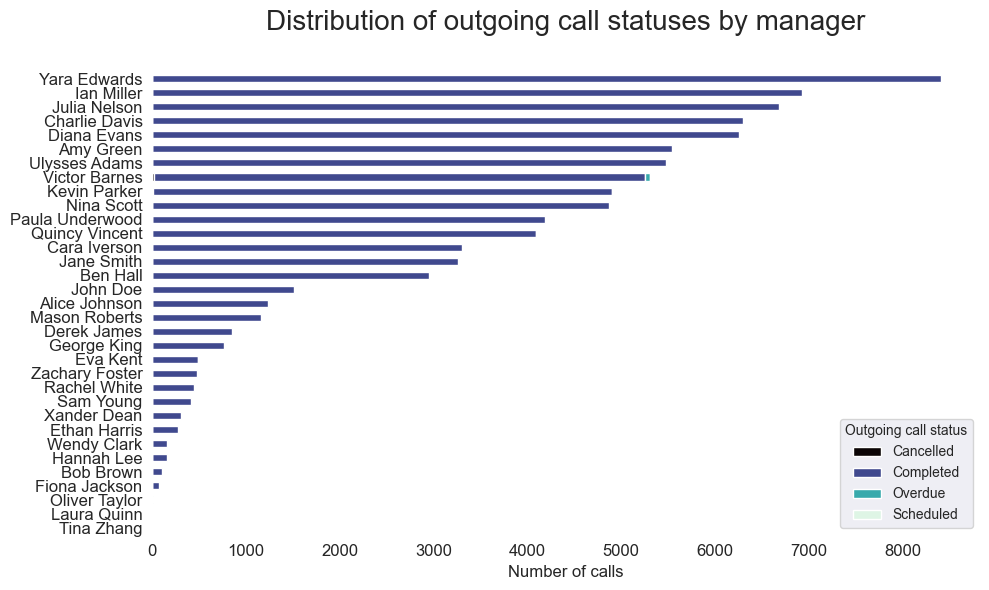

In [18]:
# Analysis of managers' calls by outgoing call status

outgoing_calls = calls[calls['outgoing_call_status'].notnull()]
manager_outgoing_call_status = pd.crosstab(outgoing_calls['calls_manager'], outgoing_calls['outgoing_call_status'])
total_outgoing_calls_per_manager = manager_outgoing_call_status.sum(axis=1)
sorted_manager_call_type = manager_outgoing_call_status.loc[total_outgoing_calls_per_manager.sort_values(ascending=True).index]

plt.figure(figsize=(10, 6))
ax = sorted_manager_call_type.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='mako')
ax.set_facecolor('none')
plt.title('Distribution of outgoing call statuses by manager', fontsize=20, pad=30)
plt.xlabel('Number of calls', fontsize=12)
plt.xticks(fontsize=12)
plt.ylabel('', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Outgoing call status')

plt.tight_layout()
plt.savefig('analysis_of_outgoing_call_status.svg')
plt.show()

## Summary statistics for Contacts:

- mean
- median
- mode
- range

In [19]:
contacts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18547 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   contact_id       18547 non-null  object        
 1   contact_manager  18547 non-null  category      
 2   created_time     18547 non-null  datetime64[ns]
 3   modified_time    18547 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](2), object(1)
memory usage: 597.9+ KB


In [20]:
contacts.describe()

,created_time,modified_time
count,18547,18547
mean,2024-01-24 14:09:50.977516544,2024-02-15 07:51:05.363670784
min,2023-06-27 11:28:00,2023-07-06 10:54:00
25%,2023-11-15 16:55:30,2023-12-09 13:06:00
50%,2024-02-01 18:32:00,2024-02-28 22:44:00
75%,2024-04-12 16:40:30,2024-04-26 22:08:00
max,2024-06-21 15:30:00,2024-06-21 15:32:00


In [21]:
print(contacts[['created_time', 'modified_time']].agg(['min', 'max', 'median']))
print("Mode created_time (date):", contacts['created_time'].dt.date.mode()[0])
print("Mode modified_time (date):", contacts['modified_time'].dt.date.mode()[0])

              created_time       modified_time
min    2023-06-27 11:28:00 2023-07-06 10:54:00
max    2024-06-21 15:30:00 2024-06-21 15:32:00
median 2024-02-01 18:32:00 2024-02-28 22:44:00
Mode created_time (date): 2024-04-16
Mode modified_time (date): 2024-04-16


### Key observations

The mode matches for `created_time` and `modified_time` (**2024-04-16**). There may have been a **mass upload or update** of a large number of contacts on that day.


## Analysis of categorical fields in Contacts

In [22]:
contacts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18547 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   contact_id       18547 non-null  object        
 1   contact_manager  18547 non-null  category      
 2   created_time     18547 non-null  datetime64[ns]
 3   modified_time    18547 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](2), object(1)
memory usage: 597.9+ KB


### contact_manager

Analysis of contact distribution by manager

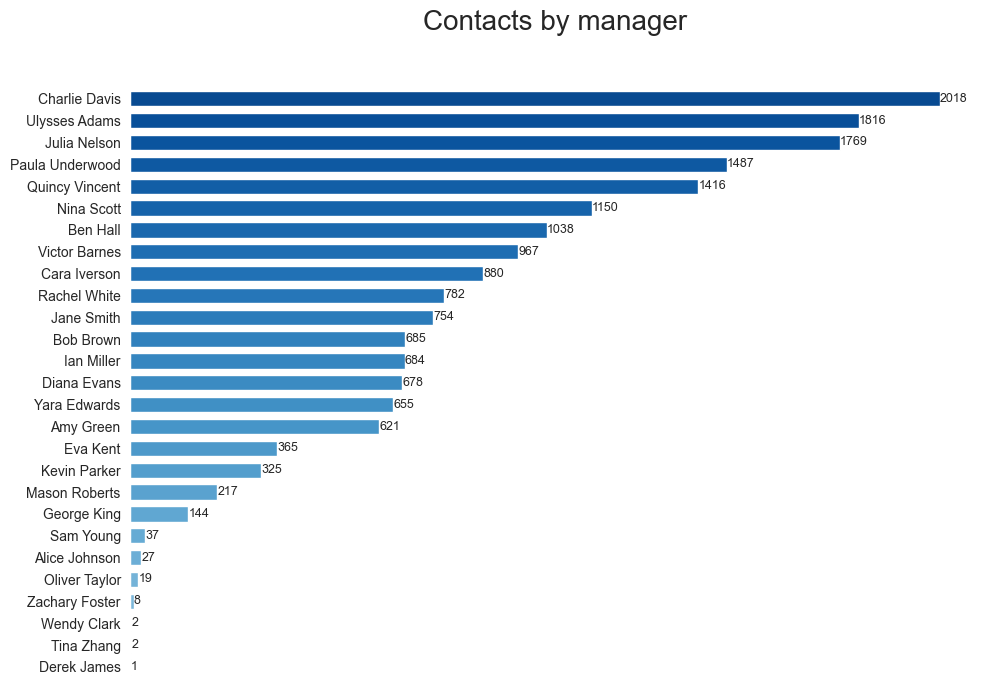

In [23]:
manager_stats = contacts['contact_manager'].value_counts()

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(manager_stats)))
ax = manager_stats.sort_values().plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.gca().set_facecolor('none')
plt.title('Contacts by manager', fontsize=20, pad=40, loc='center')
ax.set_ylabel('')

# Remove X-axis values
ax.set_xticklabels([])
ax.set_xticks([])


# Add numbers at the end of each bar
for i, (manager, count) in enumerate(manager_stats.sort_values().items()):
    ax.text(count + 0.5, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('manager_distribution.svg')
plt.show()

## Summary statistics for Spend:

- mean
- median
- mode
- range

In [24]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19862 entries, 0 to 20778
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   spend_date      19862 non-null  datetime64[ns]
 1   spend_source    19862 non-null  category      
 2   spend_campaign  19862 non-null  category      
 3   impressions     19862 non-null  int64         
 4   spend           19862 non-null  float64       
 5   clicks          19862 non-null  int64         
 6   ad_group        19862 non-null  category      
 7   ad              19862 non-null  object        
dtypes: category(3), datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 989.9+ KB



Mean: 2571.6951968583226
Median: 82.0
Mode: 0
Range: 431445


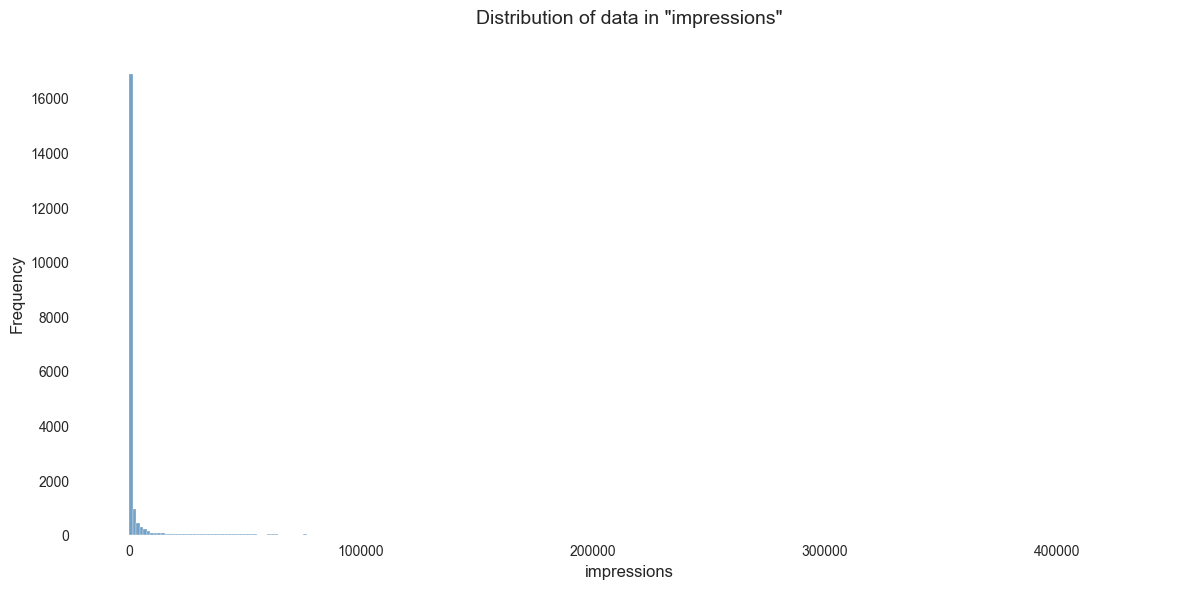

In [25]:
numeric_summary(spend, 'impressions')


Mean: 7.528116503876749
Median: 0.74
Mode: 0.0
Range: 774.0


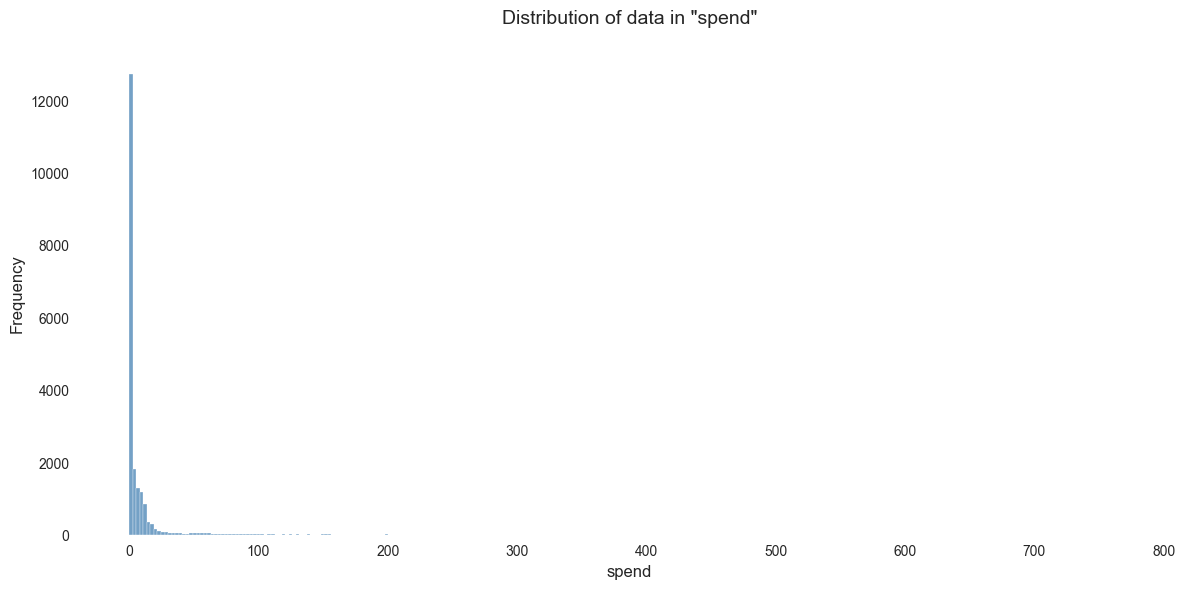

In [26]:
numeric_summary(spend, 'spend')


Mean: 25.095911791360386
Median: 2.0
Mode: 0
Range: 2415


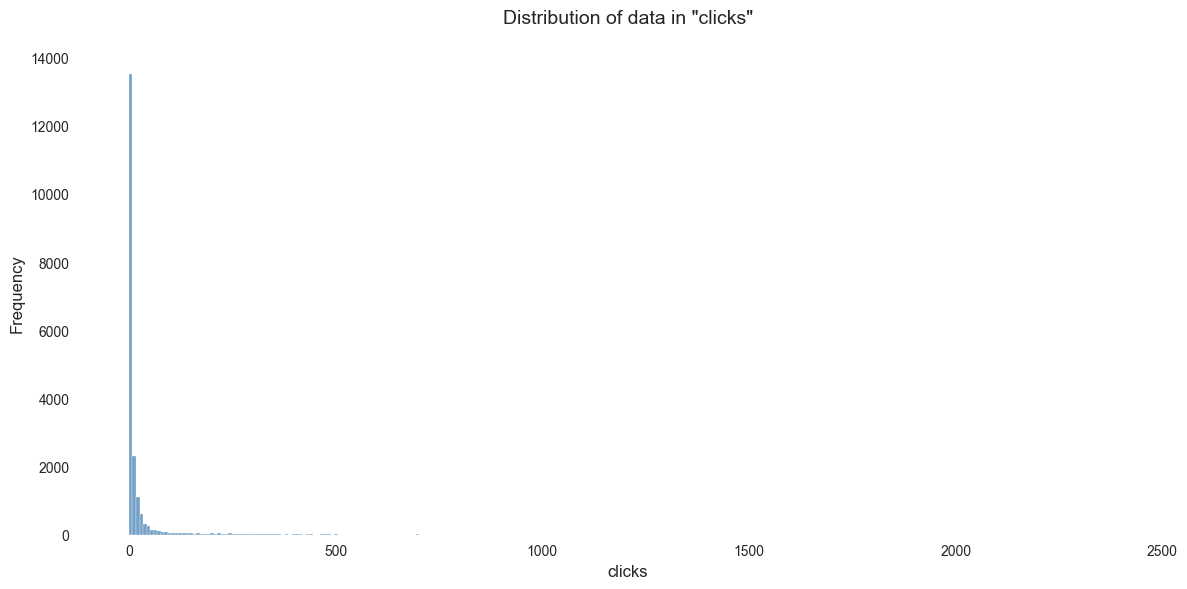

In [27]:
numeric_summary(spend, 'clicks')

In [28]:
spend[spend['clicks'] != 0].describe()

,spend_date,impressions,spend,clicks
count,11971,11971.000000,11971.000000,11971.000000
mean,2024-01-16 22:24:22.133489408,4248.852727,12.291738,41.638543
min,2023-07-03 00:00:00,0.000000,0.000000,1.000000
25%,2023-10-19 00:00:00,110.500000,0.970000,3.000000
50%,2024-01-28 00:00:00,522.000000,4.250000,10.000000
75%,2024-04-16 00:00:00,1500.000000,10.585000,24.000000
max,2024-06-21 00:00:00,431445.000000,774.000000,2415.000000
std,NaN,14821.762516,34.289223,108.991673


### Key observations:

There are pronounced spikes in activity. Likely individual days with large advertising campaigns.

## Analysis of categorical fields in Spend

### spend_source

In [29]:
spend['spend_source'].value_counts()

spend_source
Facebook Ads      9569
Tiktok Ads        2985
Youtube Ads       1784
Google Ads        1266
Telegram posts     836
Webinar            766
Bloggers           632
SMM                571
Organic            514
CRM                355
Test               262
Partnership        234
Offline             61
Radio               27
Name: count, dtype: int64

In [30]:
spend['spend_source'].value_counts()

spend_source
Facebook Ads      9569
Tiktok Ads        2985
Youtube Ads       1784
Google Ads        1266
Telegram posts     836
Webinar            766
Bloggers           632
SMM                571
Organic            514
CRM                355
Test               262
Partnership        234
Offline             61
Radio               27
Name: count, dtype: int64

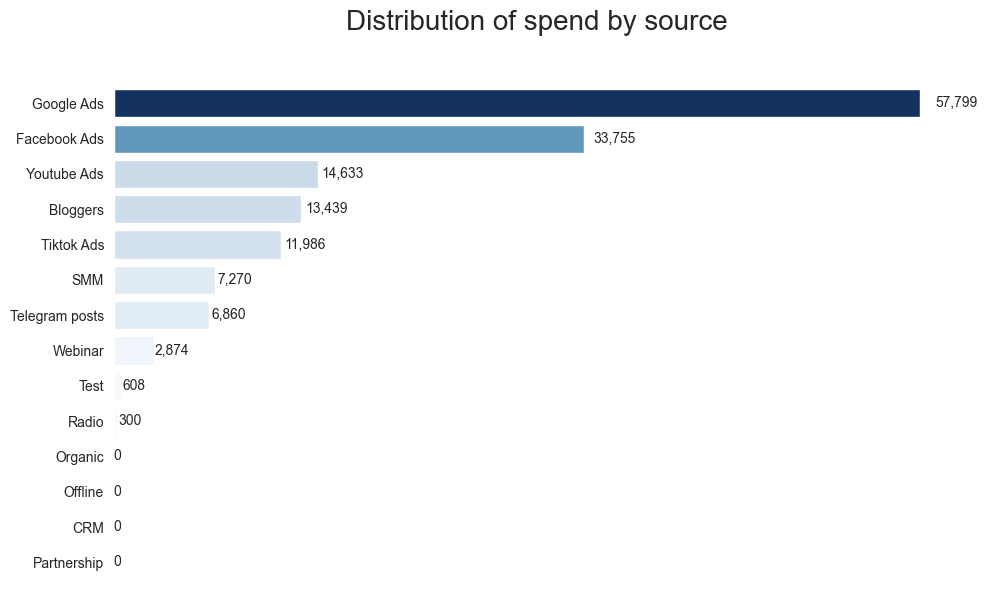

In [31]:
# Distribution of spend by source

spend_by_source = spend.groupby('spend_source', observed=True)['spend'].sum().sort_values(ascending=False)

spend_by_source_sorted = spend_by_source.sort_values(ascending=False)
sorted_spends = spend_by_source.sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=spend_by_source_sorted.values, y=spend_by_source_sorted.index, 
                 hue=spend_by_source_sorted.values, palette='Blues', 
                 order=sorted_spends, legend=False)
ax.set_facecolor('none')

plt.title('Distribution of spend by source', fontsize=20, pad=40)

# Remove X-axis values
ax.set_xticklabels([])
ax.set_xticks([])

# Remove Y-axis label
ax.set_ylabel('')

# Show the amount next to the bar
for i, (source, value) in enumerate(spend_by_source_sorted.items()):
    ax.text(value + (value * 0.02), i, f'{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('analysis_of_source_spend.svg')
plt.show()

In [32]:
spend_by_source_sorted

spend_source
Google Ads        57798.60
Facebook Ads      33754.72
Youtube Ads       14633.33
Bloggers          13439.00
Tiktok Ads        11985.67
SMM                7269.52
Telegram posts     6860.36
Webinar            2874.04
Test                608.21
Radio               300.00
Organic               0.00
Offline               0.00
CRM                   0.00
Partnership           0.00
Name: spend, dtype: float64

## Summary statistics for Deals:

- mean
- median
- mode
- range

In [33]:
deals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21564 entries, 0 to 21592
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   deals_id             21564 non-null  object         
 1   deal_manager         21564 non-null  category       
 2   closing_date         14638 non-null  datetime64[ns] 
 3   quality              21564 non-null  category       
 4   stage                21564 non-null  category       
 5   lost_reason          16165 non-null  category       
 6   page                 21564 non-null  category       
 7   deal_campaign        16399 non-null  object         
 8   sla                  15518 non-null  timedelta64[ns]
 9   content              14125 non-null  object         
 10  term                 12431 non-null  object         
 11  source               21564 non-null  category       
 12  payment_type         989 non-null    category       
 13  product              


Mean: 10.199387357282093
Median: 11.0
Mode: 11
Range: 5


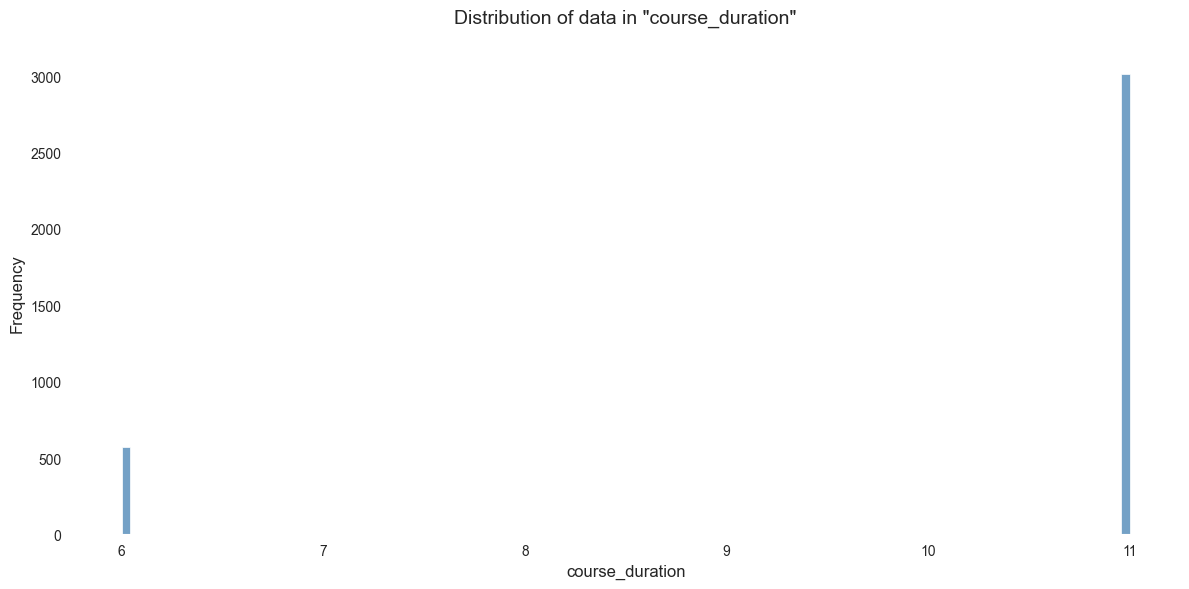

In [34]:
numeric_summary(deals, 'course_duration')


Mean: 953.7507833212823
Median: 1000.0
Mode: 1000
Range: 11500


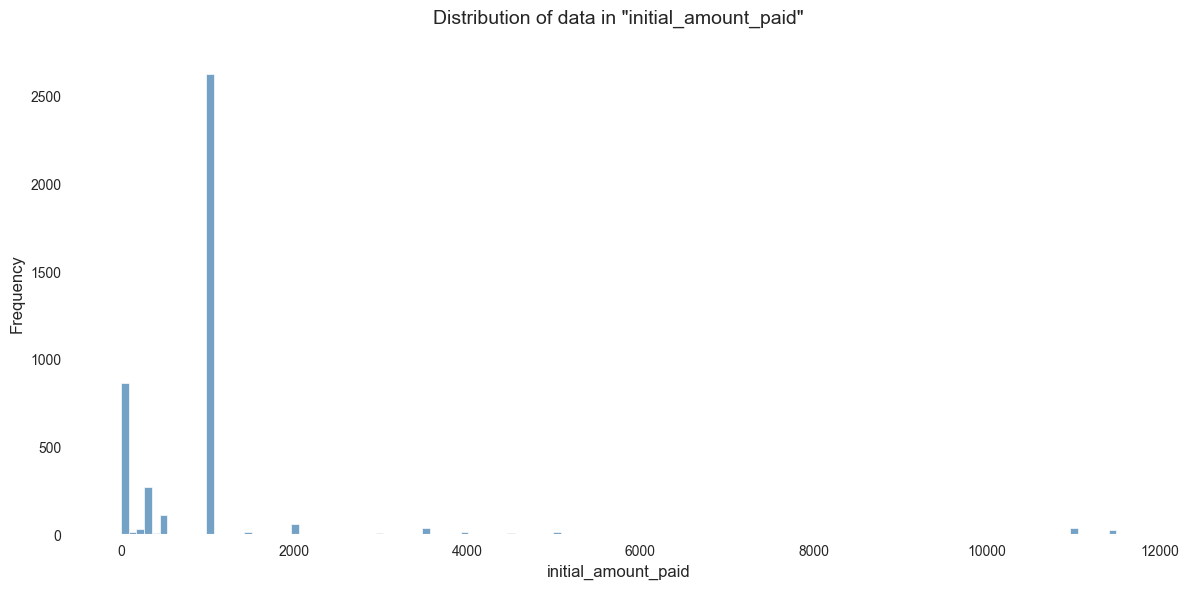

In [35]:
numeric_summary(deals, 'initial_amount_paid')


Mean: 7156.083233389302
Median: 11000.0
Mode: 11000
Range: 11500


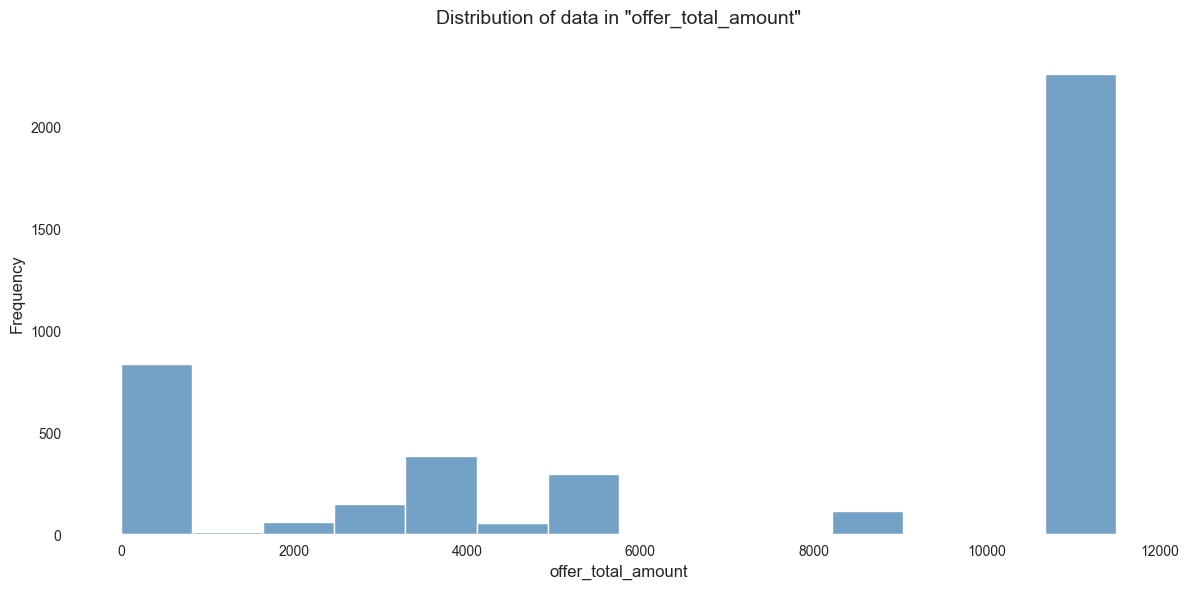

In [36]:
numeric_summary(deals, 'offer_total_amount')


Mean: 115926.85507152983
Median: 19916.0
Mode: 611.0
Range: 26908461.0


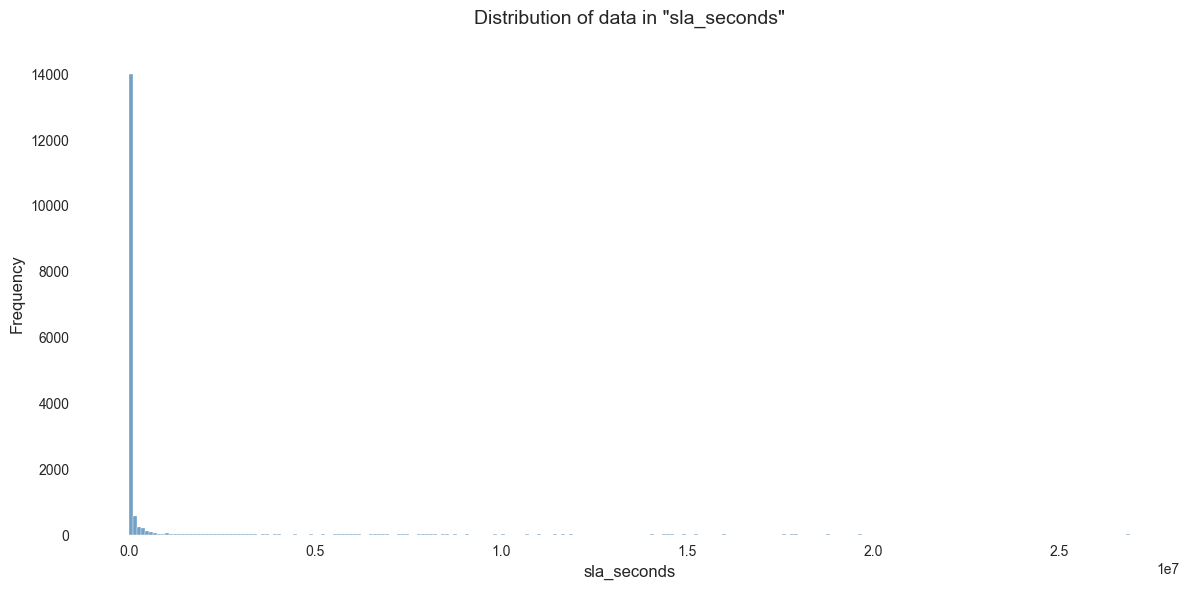

In [37]:
deals['sla_seconds'] = deals['sla'].dt.total_seconds()
sla_clean = deals[['sla_seconds']].dropna()

numeric_summary(sla_clean, 'sla_seconds')


In [38]:
# to remove outliers we use the 95th percentile
# presumably, many deals close automatically (e.g., online payment)
upper = deals['sla_seconds'].quantile(0.95)
print(f"95% of data up to: {upper:.0f} sec")

95% of data up to: 291971 sec


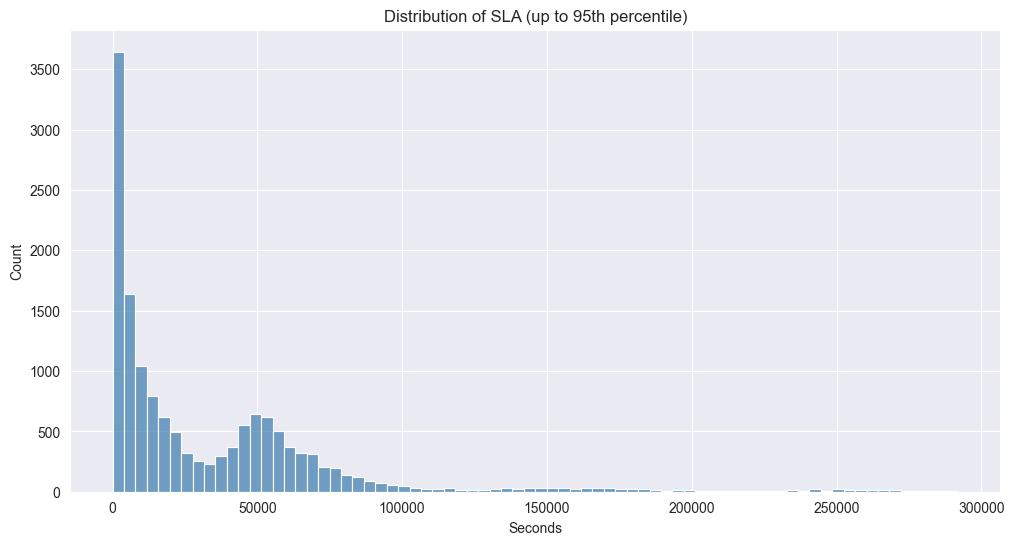

In [39]:
plt.figure(figsize=(12, 6))
sns.histplot(deals[deals['sla_seconds'] <= upper]['sla_seconds'], bins='auto', color='steelblue')
plt.title('Distribution of SLA (up to 95th percentile)')
plt.xlabel('Seconds')
plt.show()

### Key observations

- **Distribution is right-skewed** — most deals have low SLA values, with a tail stretching toward longer times
- **Peak on the left** — the majority of deals close quickly
- **Spread of up to 95% of data** — from minutes to ~83 hours (3.5 days)
- **Mean is higher than median** — due to the influence of longer deals


## Analysis of categorical fields in Deals

In [40]:
deals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21564 entries, 0 to 21592
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   deals_id             21564 non-null  object         
 1   deal_manager         21564 non-null  category       
 2   closing_date         14638 non-null  datetime64[ns] 
 3   quality              21564 non-null  category       
 4   stage                21564 non-null  category       
 5   lost_reason          16165 non-null  category       
 6   page                 21564 non-null  category       
 7   deal_campaign        16399 non-null  object         
 8   sla                  15518 non-null  timedelta64[ns]
 9   content              14125 non-null  object         
 10  term                 12431 non-null  object         
 11  source               21564 non-null  category       
 12  payment_type         989 non-null    category       
 13  product              

### deal_manager

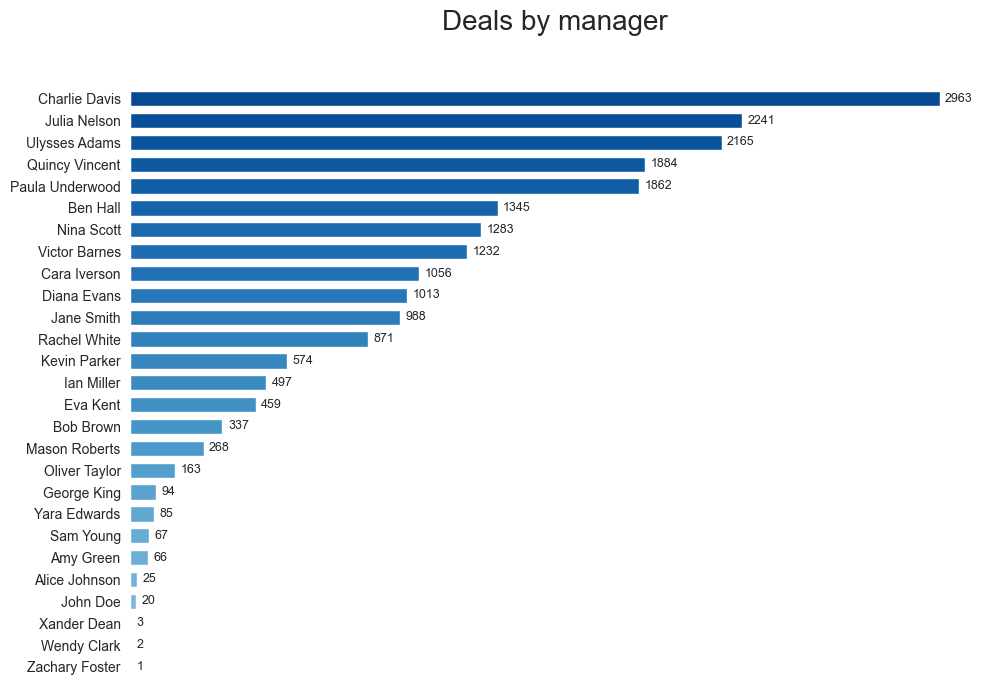

In [41]:
# Analysis of deals by manager
counts = deals['deal_manager'].value_counts()

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(counts)))
ax = counts.sort_values().plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Deals by manager', fontsize=20, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (manager, val) in enumerate(counts.sort_values().items()):
    ax.text(val + 20, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('deals_by_manager.svg')
plt.show()

### quality

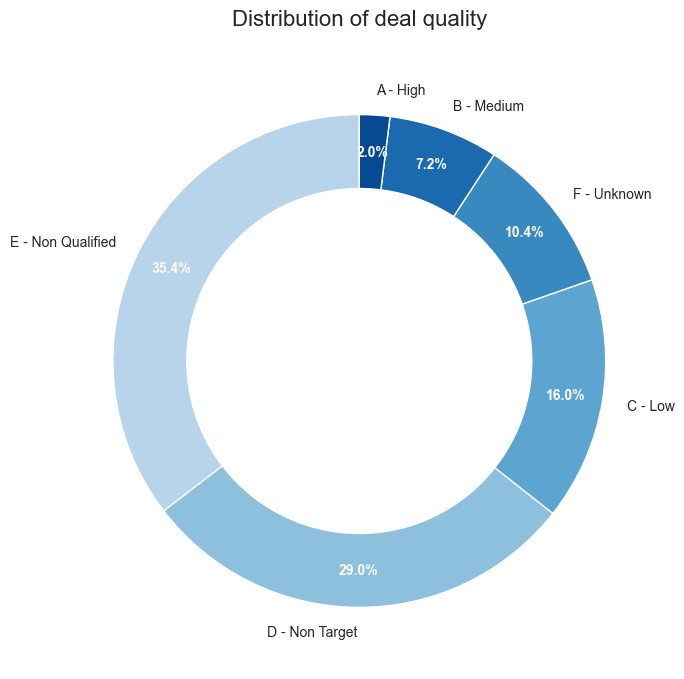

In [42]:
# Quality analysis (donut chart)
deals_quality = deals['quality'].value_counts()

plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(deals_quality)))
wedges, texts, autotexts = plt.pie(deals_quality, labels=deals_quality.index, autopct='%1.1f%%', 
                                    colors=colors, startangle=90, pctdistance=0.85)

# Percentage numbers in white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add hole (donut)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='white'))

plt.title('Distribution of deal quality', fontsize=16, pad=20)
plt.savefig('analysis_of_quality.svg')
plt.show()

### stage

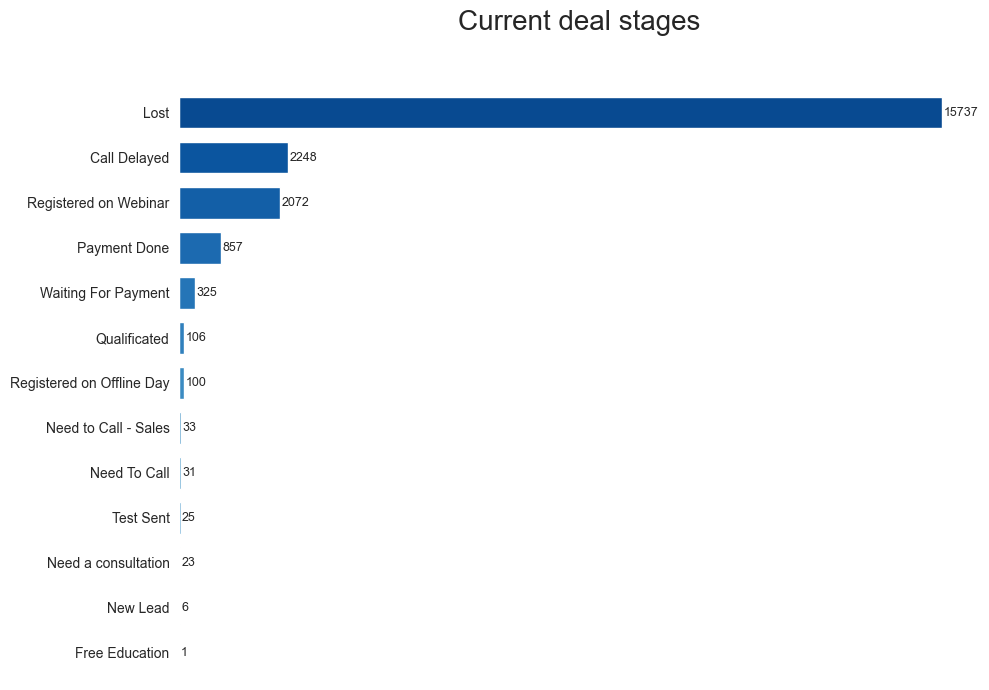

In [43]:
# Analysis of current deal stages
counts = deals['stage'].value_counts()

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(counts)))
ax = counts.sort_values().plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Current deal stages', fontsize=20, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (manager, val) in enumerate(counts.sort_values().items()):
    ax.text(val + 30, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('stage.svg')
plt.show()

Lost — 15,737 deals (73%) is a critical point for the business.

**Possible reasons:**
- Low-quality leads
- Weak objection handling or sales scripts
- High price or long approval cycle
- Managers do not follow through deals to payment

**What to do:**
1. Analyze lost deals by manager — identify systematic underperformers
2. Analyze at which stage the loss occurs (by funnel)
3. Check lead quality by source
4. Implement a post-mortem for each lost deal

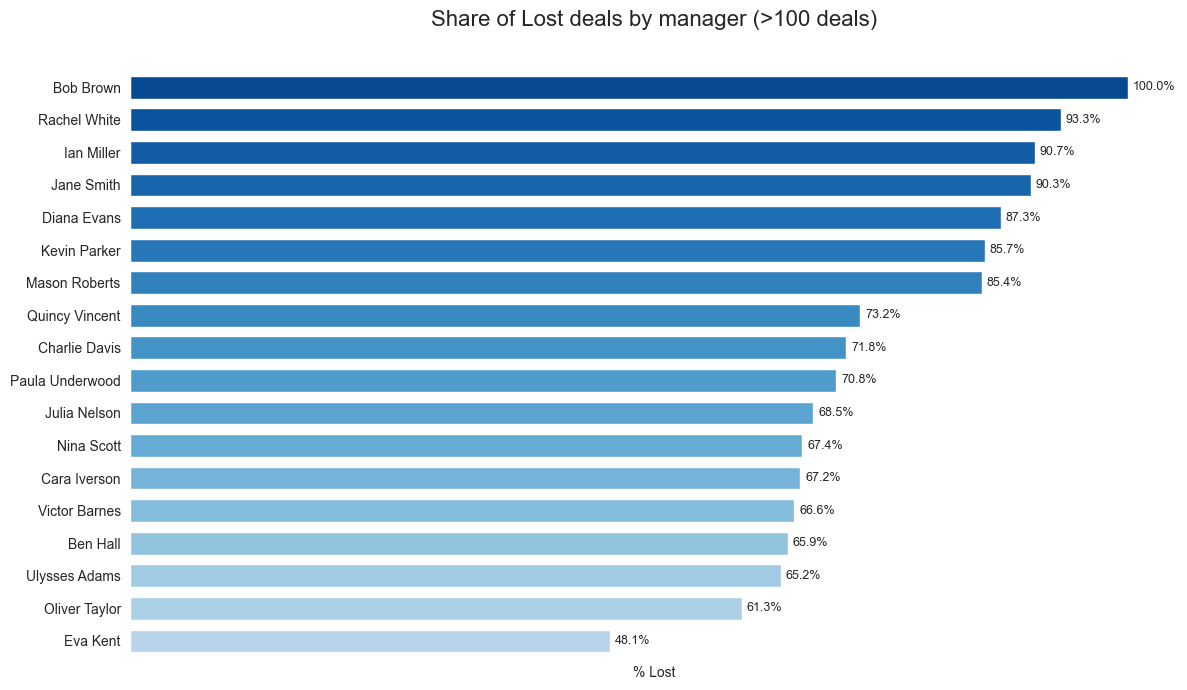

In [44]:
# Analysis of Lost deals by manager (>100 deals)
deals['is_lost'] = deals['stage'] == 'Lost'
pivot = pd.crosstab(deals['deal_manager'], deals['is_lost'])
pivot.columns = ['Other', 'Lost']

# Filter >100 deals and % Lost
pivot = pivot[pivot.sum(axis=1) > 100].copy()
pivot['% Lost'] = (pivot['Lost'] / pivot.sum(axis=1) * 100).round(1)
pivot = pivot.sort_values('% Lost')

# Chart
plt.figure(figsize=(12, 7))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(pivot)))
ax = pivot['% Lost'].plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Share of Lost deals by manager (>100 deals)', fontsize=16, pad=30)
plt.xlabel('% Lost')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, val in enumerate(pivot['% Lost']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('lost_percent_by_manager.svg')
plt.show()

### Key observations

- **Bob Brown — 100% Lost**  
  Requires immediate analysis: perhaps the manager only works with problematic leads, conducts negotiations incorrectly, or does not record successful deals in the system.

- **High share of Lost for the majority**  
  12 out of 18 managers have a lost deal percentage exceeding 70%, indicating systemic conversion problems.
- **Efficiency leader — Eva Kent**  
  Lowest share of Lost (48.1%) — the best result among managers with high workload.

### lost_reason

In [45]:
deals['lost_reason'].value_counts()

lost_reason
Doesn't Answer                             4134
Changed Decision                           2143
Duplicate                                  1771
Non target                                 1761
Stopped Answering                          1588
Invalid number                             1481
needs time to think                         655
Expensive                                   626
Conditions are not suitable                 531
Next stream                                 288
Inadequate                                  176
Gutstein refusal                            172
Considering a different direction in IT     148
Not for myself                              144
Does not speak English                      138
Didn't leave an application                 133
Thought for free                            110
Does not know how to use a computer          50
Unknown                                      47
Went to Rivals                               47
The contract did not fit    

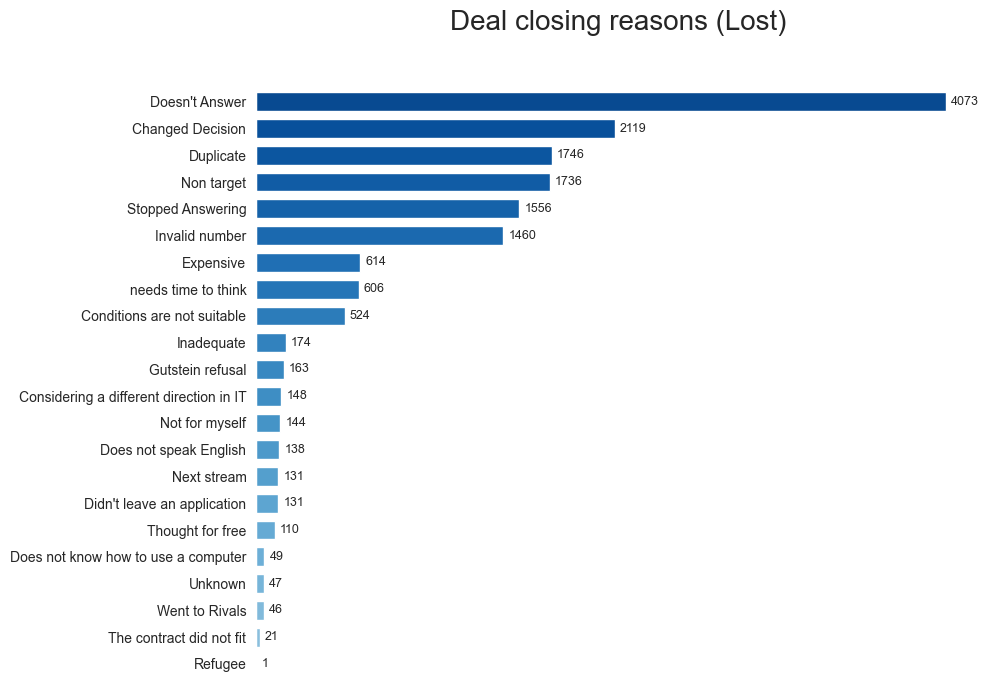

In [46]:
# Analysis of deal closing reasons (Lost)

deals_lost = deals[deals['stage'] == 'Lost']['lost_reason'].value_counts()

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(deals_lost)))
ax = deals_lost.sort_values().plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Deal closing reasons (Lost)', fontsize=20, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (reason, val) in enumerate(deals_lost.sort_values().items()):
    ax.text(val + 30, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analysis_of_lost_reason.svg')
plt.show()

### source

### Analysis of lead distribution by source

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_35771/4084341644.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



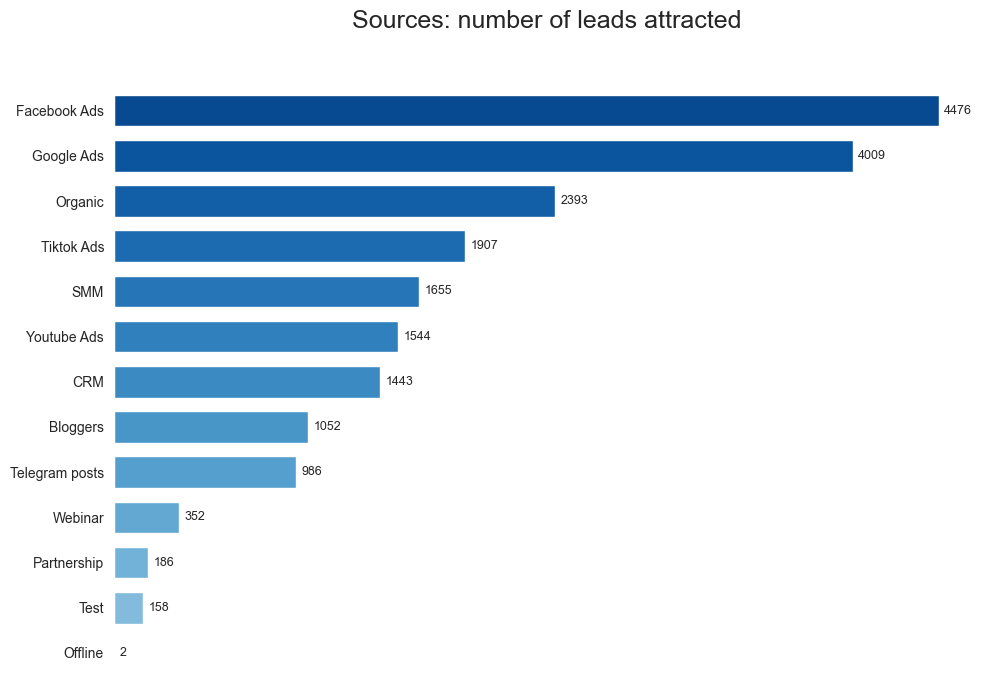

In [47]:
# Unique leads by source
unique_leads_by_source = deals.groupby('source')['contact_name'].nunique().sort_values()

plt.figure(figsize=(10, 7), facecolor='none')
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(unique_leads_by_source)))
ax = unique_leads_by_source.plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Sources: number of leads attracted', fontsize=18, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (channel, val) in enumerate(unique_leads_by_source.items()):
    ax.text(val + 30, i, str(int(val)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('unique_leads_by_channel.png', transparent=True)
plt.show()

In [48]:
unique_leads_by_source.sort_index()

source
Bloggers          1052
CRM               1443
Facebook Ads      4476
Google Ads        4009
Offline              2
Organic           2393
Partnership        186
SMM               1655
Telegram posts     986
Test               158
Tiktok Ads        1907
Webinar            352
Youtube Ads       1544
Name: contact_name, dtype: int64

The graph shows a pronounced unevenness.

**Facebook Ads** and **Google Ads** are the main traffic drivers, collectively generating almost 8,500 leads.

**Organic** is in third place (2,393), significantly outperforming other free channels.

**TikTok**, **SMM** and **Youtube Ads** show consistent results in the range of 1,500–1,900 leads, forming the "middle tier".

**Webinars**, **partnerships** and **offline activities** bring minimal results — totaling less than 600 leads.

The flow from Facebook is tens of times higher than the results from Telegram and affiliate programs, indicating a bias in the marketing strategy.

## Dominance of paid channels
**Facebook Ads** (4,476) and **Google Ads** (4,009) are the main traffic drivers, collectively generating almost 8,500 leads. Paid channels occupy leading positions in terms of audience volume attracted.

### payment_type

In [49]:
deals['payment_type'].value_counts()

payment_type
Unknown               494
Recurring Payments    350
One Payment           140
Reservation             5
Name: count, dtype: int64

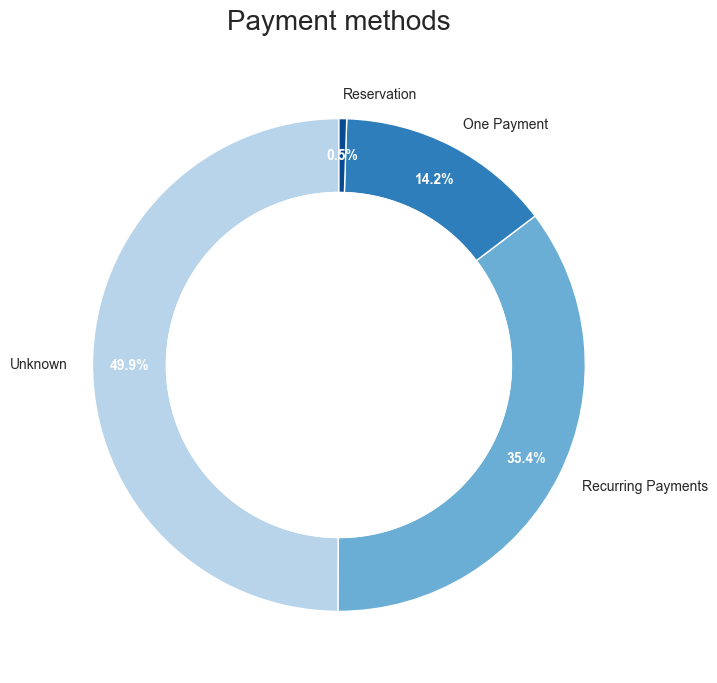

In [50]:
# Distribution by payment type
deals_payment_type = deals['payment_type'].value_counts()

plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(deals_payment_type)))
wedges, texts, autotexts = plt.pie(deals_payment_type, labels=deals_payment_type.index, autopct='%1.1f%%', 
                                    colors=colors, startangle=90, pctdistance=0.85)

# Only percentage numbers in white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add hole (donut)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='white'))

plt.gca().add_artist(plt.Circle((0, 0), 0.70, fc='none'))
plt.title('Payment methods', fontsize=20, pad=20)
plt.savefig('analysis_of_payment_type.svg')
plt.show()

### Conclusions

**Critical data deficit**
49.9% of deals have an undefined payment type (Unknown). This means that for half of the database, it is impossible to track the customer's financial behavior model.

**Popularity of Recurring Payments**
Among known methods, Recurring Payments dominate (35.4%). This is a positive sign, indicating the existence of a base with regular recurring charges (subscriptions).

**One-time payments**
The share of One Payment is only 14.2%, which is 2.5 times smaller than the share of auto-payments.

**Reservation**
The Reservation category (0.5%) is barely expressed, indicating the absence of a system for advance paid reservation of services or goods.

### product

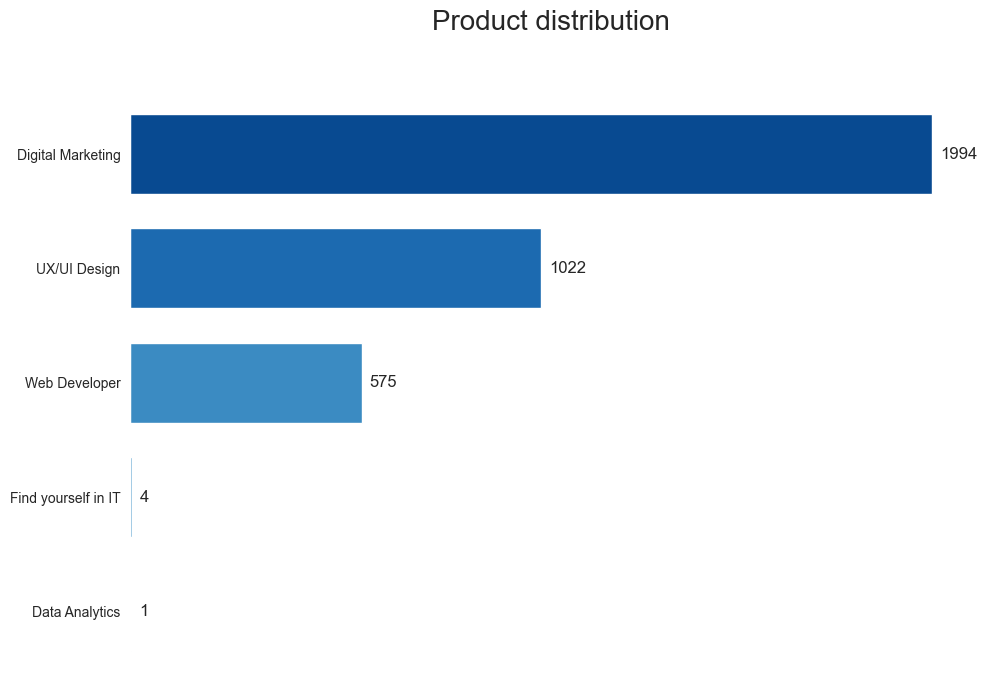

In [51]:
# Distribution of leads by product (based on available data)
product_stats = deals['product'].value_counts().sort_values()

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(product_stats)))
ax = product_stats.plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Product distribution', fontsize=20, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (product, val) in enumerate(product_stats.items()):
    ax.text(val + 20, i, str(int(val)), va='center', fontsize=12)

plt.tight_layout()
plt.savefig('product_distribution.svg')
plt.show()

### Conclusions

**Clear leader**  
Digital Marketing — 1,994 leads, which is 2 times higher than UX/UI Design (1,022 leads).

**Dormant directions**  
Find yourself in IT and Data Analytics brought a total of only 5 leads — either the directions are irrelevant or not being promoted.

### education_type

In [52]:
deals['education_type'].value_counts()

education_type
Morning    3028
Evening     411
Name: count, dtype: int64

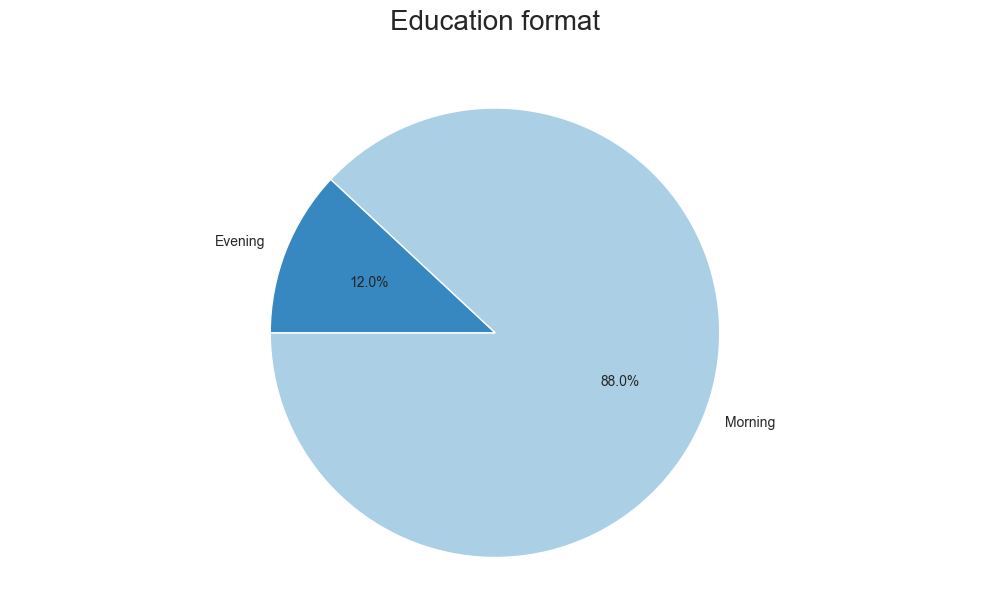

In [53]:
# Distribution by education type

deals_education_type = deals['education_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(deals_education_type, labels=deals_education_type.index, autopct='%1.1f%%',
        colors=sns.color_palette('Blues', len(deals_education_type)), startangle=180)
plt.title(f'Education format', fontsize=20, pad=40, loc='center')
plt.axis('equal')
plt.tight_layout()
plt.savefig('analysis_of_education_type.svg')
plt.show()

### Conclusion

The market requires **Morning** (88% of demand)
Other directions and evening groups are practically not in demand.

### level_of_deutsch

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_35771/1492155642.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



level_of_deutsch
Unknown      0
C2           3
A0          11
A1          25
C1          27
A2         148
B2         171
B1         808
Name: contact_name, dtype: int64


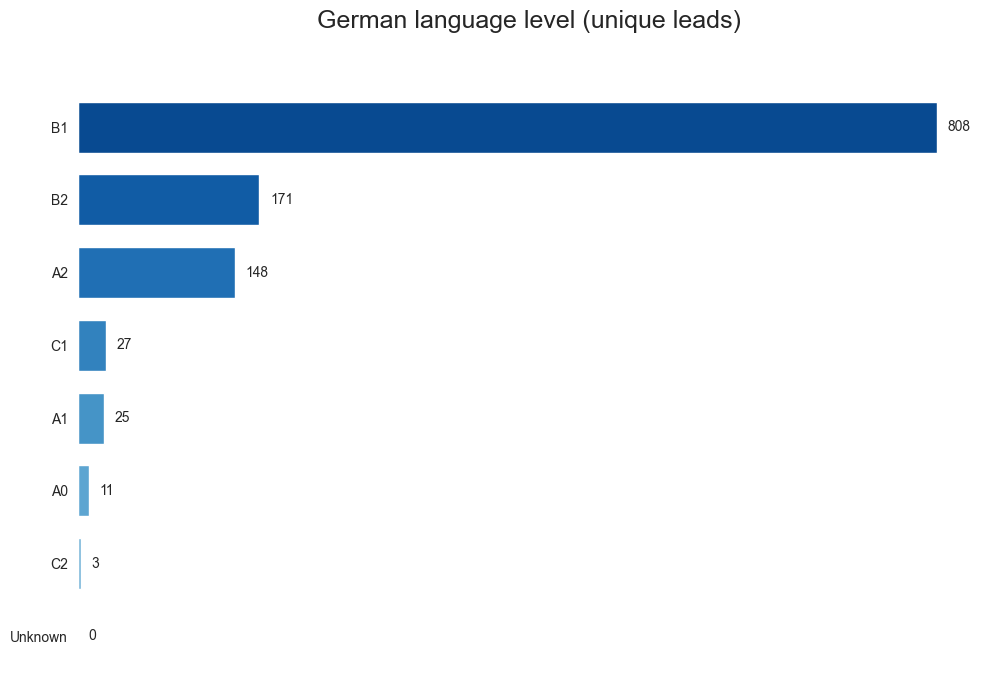

In [54]:
# Analysis of German language level (unique leads)
unique_levels = deals[deals['level_of_deutsch'] != 'Unknown'].groupby('level_of_deutsch')['contact_name'].nunique().sort_values()
print(unique_levels)

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(unique_levels)))
ax = unique_levels.plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('German language level (unique leads)', fontsize=18, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (level, val) in enumerate(unique_levels.items()):
    ax.text(val + 10, i, str(int(val)), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('analysis_of_level_of_german_unique.svg')
plt.show()


### Conclusion on German language level

- **The vast majority of leads have level B1** — this is the most common language proficiency level among customers
- **Pattern:** school admission conditions require German proficiency no lower than B1 for payment from government grants, hence the natural clustering of leads at this level

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_35771/3568677808.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



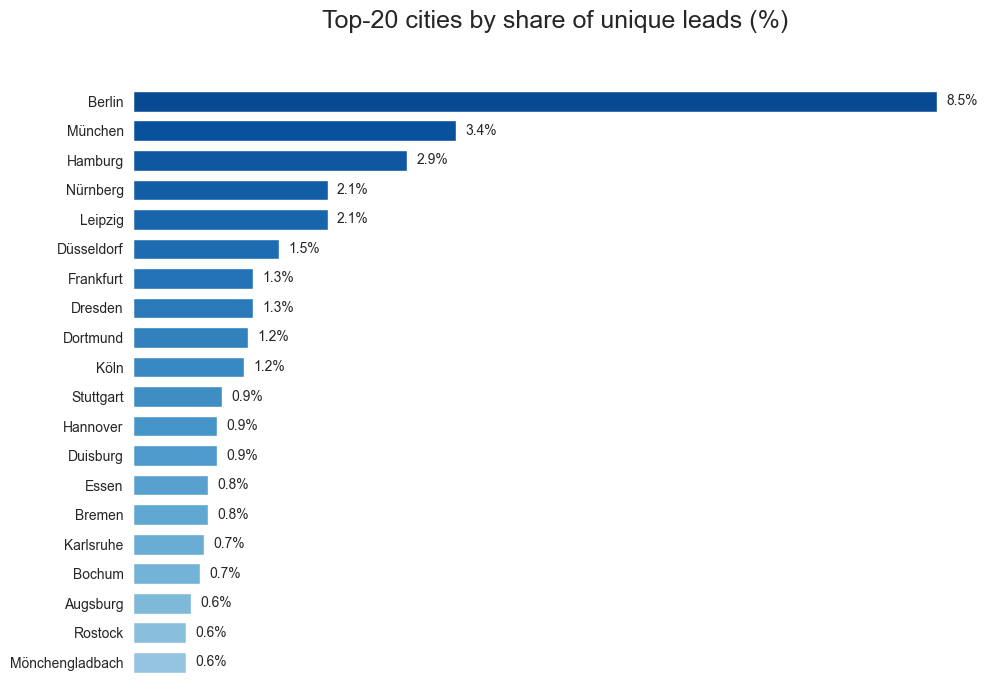

Total unique leads: 2142


In [55]:
# Analysis of cities (unique leads) - in percentages
unique_cities = deals[deals['city'] != 'Unknown'].groupby('city')['contact_name'].nunique().sort_values(ascending=False)

# Calculate percentages
total = unique_cities.sum()
percentages = (unique_cities / total * 100).head(20)

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(percentages)))
ax = percentages.sort_values().plot(kind='barh', color=colors, width=0.7)
ax.set_facecolor('none')
plt.title('Top-20 cities by share of unique leads (%)', fontsize=18, pad=40, loc='center')
ax.set_ylabel('')
ax.set_xticklabels([])
ax.set_xticks([])

for i, (city, val) in enumerate(percentages.sort_values().items()):
    ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('analysis_of_cities_unique_percent.svg')
plt.show()

# Display total statistics
print(f"Total unique leads: {total}")

### Conclusions:
**Berlin is the absolute leader.** The capital generates 8.5% of unique leads, which is 2.5 times more than the nearest competitor (Munich).

**Concentration in megacities.** The top 3 cities (Berlin, Munich, Hamburg) provide the main flow. Together they bring more leads than the next 10 cities in the list combined.